### **Imports & Configurations**


In [1]:
import warnings
from typing import List, Tuple

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, classification_report, mean_absolute_error

# ==========================================
# Configurations & Display Settings
# ==========================================
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

TICKER: str = "AAPL"
FORECAST_DAYS: int = 5

FEATURE_COLS: List[str] = [
    "Open", "High", "Low", "Close", "Volume",
    "Daily_Range", "Intraday_Return", "Overnight_Gap",
    "Close_to_10d_High", "Close_to_10d_Low",
    "RSI_14", "MACD", "MACD_Signal", "MACD_Histogram",
]

### **Data Ingestion**


In [2]:
def fetch_historical_data(ticker_symbol: str, period: str = "3y") -> pd.DataFrame:
    """Fetch historical daily data from yfinance."""
    print(f"Fetching {period} of historical data for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)
    df = ticker.history(period=period)

    if df.empty:
        raise ValueError(f"No data returned for ticker '{ticker_symbol}'")
    return df


raw_data = fetch_historical_data(TICKER, period="3y")
raw_data.tail(3)

Fetching 3y of historical data for AAPL...


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-18 00:00:00-04:00,252.630005,254.940002,249.000000,249.940002,35757900,0.0,0.0
2026-03-19 00:00:00-04:00,249.399994,251.830002,247.300003,248.960007,34864100,0.0,0.0
2026-03-20 00:00:00-04:00,248.110001,249.199905,246.000000,247.990005,88331081,0.0,0.0


### **Feature & Target Engineering**


In [3]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Generate technical indicators and derived features using vectorized operations."""
    data = df.copy()

    # Basic price features
    data["Daily_Range"] = data["High"] - data["Low"]
    data["Intraday_Return"] = (data["Close"] - data["Open"]) / data["Open"]

    prev_close = data["Close"].shift(1)
    data["Overnight_Gap"] = np.where(
        prev_close.notna(),
        (data["Open"] - prev_close) / prev_close,
        0,
    )

    # Rolling metrics
    rolling_high = data["High"].rolling(window=10).max()
    rolling_low = data["Low"].rolling(window=10).min()

    data["Close_to_10d_High"] = data["Close"] / rolling_high
    data["Close_to_10d_Low"] = data["Close"] / rolling_low

    # RSI (14)
    delta = data["Close"].diff()
    gain = delta.clip(lower=0).ewm(com=13, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(com=13, adjust=False).mean()

    rs = np.divide(gain, loss, out=np.zeros_like(gain), where=loss != 0)
    data["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = data["Close"].ewm(span=12, adjust=False).mean()
    ema26 = data["Close"].ewm(span=26, adjust=False).mean()

    data["MACD"] = ema12 - ema26
    data["MACD_Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()
    data["MACD_Histogram"] = data["MACD"] - data["MACD_Signal"]

    return data.dropna()


def build_unified_targets(df: pd.DataFrame, days: int = FORECAST_DAYS) -> Tuple[pd.DataFrame, str, List[str]]:
    """Create targets for both the Classifier (1-day direction) and Regressor (multi-day returns)."""
    data = df.copy()

    # 1. Classifier Target (1 if tomorrow's close > today's close, else 0)
    class_target: str = "Target_Class"
    data[class_target] = (data["Close"].shift(-1) > data["Close"]).astype(int)

    # 2. Regressor Targets (Percentage returns for the next N days)
    reg_targets: List[str] = []
    for i in range(1, days + 1):
        col = f"Return_{i}d"
        data[col] = (data["Close"].shift(-i) - data["Close"]) / data["Close"]
        reg_targets.append(col)

    return data, class_target, reg_targets


# Apply transformations
processed_features = engineer_features(raw_data)
processed_data, CLASS_TARGET, REG_TARGETS = build_unified_targets(
    processed_features, days=FORECAST_DAYS)

# Drop rows where future targets are unknown (the last 5 days of the dataset)
processed_data = processed_data.dropna(subset=REG_TARGETS)

### **Unified Training & Evaluation Engine**


In [4]:
def train_and_evaluate_models(
    data: pd.DataFrame,
    features: List[str],
    class_target: str,
    reg_targets: List[str]
) -> Tuple[RandomForestClassifier, RandomForestRegressor]:
    """Chronologically splits data, trains both models, and prints a diagnostic report."""

    # Chronological Split (80% Train, 20% Test)
    train_size = int(len(data) * 0.8)
    train_data = data.iloc[:train_size]
    test_data = data.iloc[train_size:]

    X_train, X_test = train_data[features], test_data[features]

    y_train_class, y_test_class = train_data[class_target], test_data[class_target]
    y_train_reg, y_test_reg = train_data[reg_targets], test_data[reg_targets]

    print(
        f"Dataset Split: Training on {len(X_train)} days, Testing on {len(X_test)} days.\n")

    # ==========================================
    # MODEL 1: RANDOM FOREST CLASSIFIER
    # ==========================================
    print("="*60)
    print(" 📊 MODEL 1: CLASSIFIER (Predicting Tomorrow's Direction)")
    print("="*60)

    clf_model = RandomForestClassifier(
        n_estimators=150, min_samples_split=100, max_depth=5, random_state=42, n_jobs=-1
    )
    clf_model.fit(X_train, y_train_class)

    test_preds_class = clf_model.predict(X_test)

    print(
        f"Training Accuracy: {accuracy_score(y_train_class, clf_model.predict(X_train)):.2%}")
    print(
        f"Test Accuracy:     {accuracy_score(y_test_class, test_preds_class):.2%}")
    print(
        f"Test Precision:    {precision_score(y_test_class, test_preds_class):.2%} (Accuracy when predicting UP)")
    print("\nClassification Report:")
    print(classification_report(y_test_class, test_preds_class,
          target_names=['Down (0)', 'Up (1)']))

    # ==========================================
    # MODEL 2: RANDOM FOREST REGRESSOR
    # ==========================================
    print("\n" + "="*60)
    print(" 📈 MODEL 2: REGRESSOR (Predicting 5-Day Price Horizon)")
    print("="*60)

    reg_model = RandomForestRegressor(
        n_estimators=150, max_depth=8, random_state=42, n_jobs=-1
    )
    reg_model.fit(X_train, y_train_reg)

    test_preds_reg = reg_model.predict(X_test)

    print(
        f"Training MAE: {mean_absolute_error(y_train_reg, reg_model.predict(X_train)):.4f} (Avg % error)")
    print(
        f"Test MAE:     {mean_absolute_error(y_test_reg, test_preds_reg):.4f} (Avg % error on unseen data)")

    # Visual verification of the very last day in the test set
    sample_actual = y_test_reg.iloc[-1].values
    sample_pred = test_preds_reg[-1]

    print("\nSample Forecast Verification (Last Day of Test Set):")
    for i in range(len(sample_actual)):
        print(
            f" Day {i+1} Ahead -> AI Predicted Return: {sample_pred[i]:>6.2%} | Actual Market Return: {sample_actual[i]:>6.2%}")

    return clf_model, reg_model

### **Execution**


In [5]:
# Execute the pipeline and extract the trained models
classifier, regressor = train_and_evaluate_models(
    processed_data,
    FEATURE_COLS,
    CLASS_TARGET,
    REG_TARGETS
)

Dataset Split: Training on 591 days, Testing on 148 days.

 📊 MODEL 1: CLASSIFIER (Predicting Tomorrow's Direction)
Training Accuracy: 67.85%
Test Accuracy:     50.68%
Test Precision:    51.19% (Accuracy when predicting UP)

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.50      0.44      0.47        73
      Up (1)       0.51      0.57      0.54        75

    accuracy                           0.51       148
   macro avg       0.51      0.51      0.50       148
weighted avg       0.51      0.51      0.50       148


 📈 MODEL 2: REGRESSOR (Predicting 5-Day Price Horizon)
Training MAE: 0.0130 (Avg % error)
Test MAE:     0.0278 (Avg % error on unseen data)

Sample Forecast Verification (Last Day of Test Set):
 Day 1 Ahead -> AI Predicted Return: -1.05% | Actual Market Return:  1.08%
 Day 2 Ahead -> AI Predicted Return: -1.96% | Actual Market Return:  1.64%
 Day 3 Ahead -> AI Predicted Return: -2.61% | Actual Market Return: -0.07%
 Day 

### **Visualizing the AI's Logic**


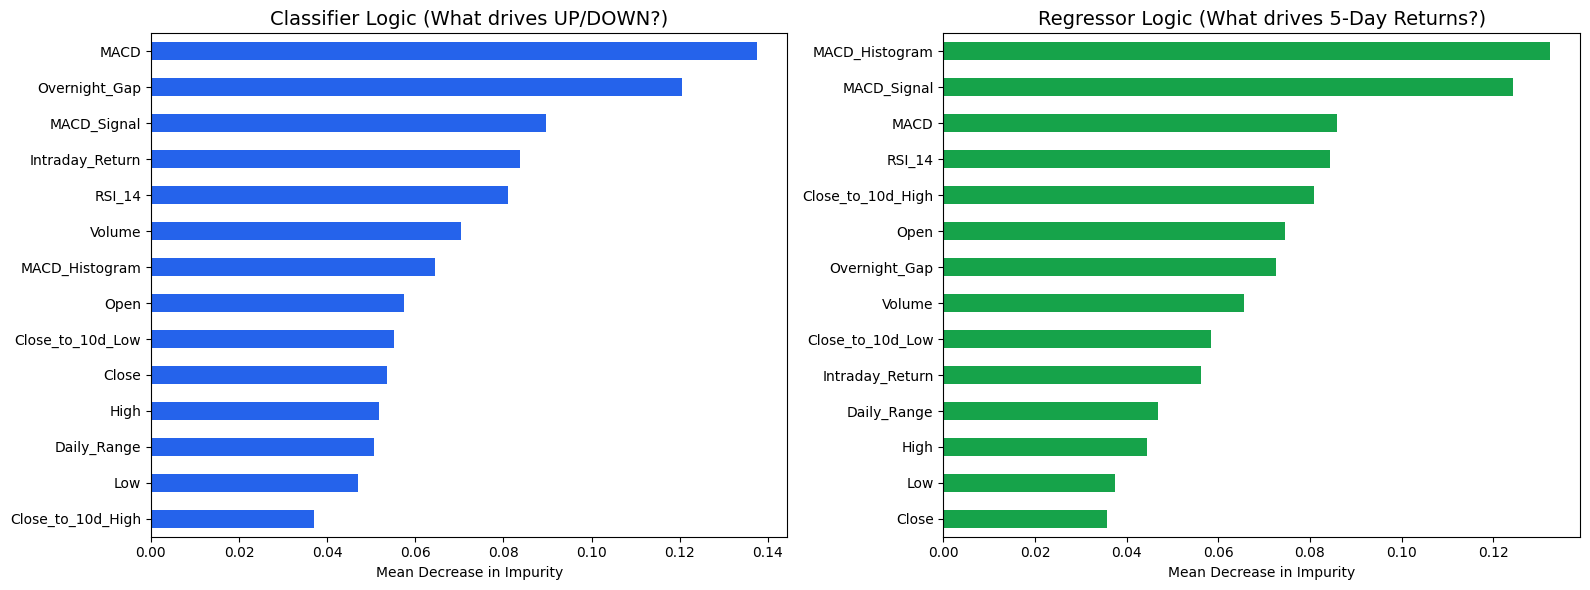

In [6]:
# Extract importances
clf_importances = pd.Series(
    classifier.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
reg_importances = pd.Series(
    regressor.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

clf_importances.plot.barh(ax=axes[0], color='#2563eb')  # Blue
axes[0].set_title("Classifier Logic (What drives UP/DOWN?)", fontsize=14)
axes[0].set_xlabel("Mean Decrease in Impurity")

reg_importances.plot.barh(ax=axes[1], color='#16a34a')  # Green
axes[1].set_title(
    f"Regressor Logic (What drives {FORECAST_DAYS}-Day Returns?)", fontsize=14)
axes[1].set_xlabel("Mean Decrease in Impurity")

fig.tight_layout()
plt.show()